# High-contrast data reduction with BREADS and NIRSpec

## Introduction

This notebook uses the HIP 65426 b NIRSpec G395H NRS2 (4-5 microns) dataset to illustrate the data processing, S/N map computation, and spectral extraction with BREADS. In this case, the central star is located within the FOV of NIRSpec. In general, one should expect to tune the various BREADS parameters and monitor the previews (PNG, HTML, GIF) that are automatically saved in the utils folder during the reduction. It is not recommended to use BREADS as an end-to-end black box due to the complexity of the data analysis.
BREADS produces a lot of warnings during the reduction; they should be harmless for the most part.

Make sure to download the BreadsPSF folder from the `google drive <https://drive.google.com/drive/folders/11GtRrZrg982UkZTHOvcGcV_EFKmQ3tVt?usp=sharing>`_. and put it in your ``breads_data`` directory.

Various package imports:

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from multiprocess import Pool
import subprocess
from astropy.io import fits

# breads jwst reduction_utils
from breads.jwst_reduction.reduction_utils import find_files_to_process
from breads.jwst_reduction.reduction_utils import run_complete_stage1_2_nirspec
from breads.jwst_reduction.reduction_utils import recenter_coordinates_per_frame_nirspec
from breads.jwst_reduction.reduction_utils import compute_normalized_stellar_spectrum
from breads.jwst_reduction.reduction_utils import compute_3dsplines
from breads.jwst_reduction.reduction_utils import cube_extraction,extract_spectrum,compute_snr_grid

# breads jwst_tools
from breads.jwst_tools.splines import plot_3dspline_residuals
from breads.jwst_tools.breadspsf import create_BreadsPSF
import breads.jwst_tools.default_nirspec as default

Some initial configurations and paths. Modify as needed for specific datasets.

In [2]:
# Write your STScI token for downloading data from the MAST archive
# See https://auth.mast.stsci.edu/info to create a token
token = "??????????????????????????"
# Make an environment variable for the token
os.environ["MAST_API_TOKEN"] = token

# To prevent numpy paralellization when using multiprocessing. (TBC if needed)
os.environ["OPENBLAS_NUM_THREADS"] = "1"   # export OPENBLAS_NUM_THREADS=1
os.environ["MKL_NUM_THREADS"] = "1"        # export MKL_NUM_THREADS=1

# Number of threads to be used for the parallelized steps in BREADS
numthreads = 8
# Base directory where the data products will be saved
base_path = '/stow/jruffio/data/JWST/nirspec/HIP_65426/' # change me
# path to your conda environment bin directory where it can find jwst_download.py
JWSTDL_path = '~/anaconda3/envs/breads_2026/bin/' # change me
# Object name used for various labeling needs
targetname = "HIP_65426"  # change me
# Simbad object name. This is for the automated Simbad query inside BREADS to get the absolute RA/Dec of the star to define the Delta RA and delta Dec coordinates of the point cloud.
simbad_name = "HIP 65426" # change me
# JWST program number
program = '8063' # change me
uncal_path = os.path.join(base_path, f'uncal_{program}') # Path where to save the uncal files
# Dates range between which the MAST query will look for the uncal data to download
date_string = '2025-07-01 2025-07-31' # change me
# Observing number for the dataset, see the JWST APT file for the program
obsnum = "obsnum06" # # change me, e.g., "obsnum05" or "obsnum06"
# detector to process
detector = "nrs2" # change me, e.g. "nrs1" or "nrs2"
grating = "G395H"# change me, e.g. "G140H", "G395H", "G395H"
# Define utils directory (for all intermediate data products, there are lots of them)
utils_dir = os.path.join(base_path,obsnum+"_"+program, grating+"_utils")
if not os.path.exists(utils_dir):
    os.makedirs(utils_dir)
# Define output directory (for extracted spectra, SNR maps, etc.)
out_dir = os.path.join(base_path,obsnum+"_"+program, grating+"_out")
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
# defines the x/y-axis sampling for computing BreadsPSF
x_vec = np.arange(-1.5,1.5, 0.02)
y_vec = np.arange(-1.5,1.5, 0.02)
# defines the x/y-axis sampling for computing cube extraction
ra_vec = np.arange(-2,2, 0.05)
dec_vec = np.arange(-2,2, 0.05)
# Using BREADS default wavelength sampling when interpolating the data on a regular wavelength grid
wv_sampling = default.wv_sampling_dict[grating][detector]

# For known planets, define their astrometry here. This is used for various tasks like masking, plotting, or initial spectral extraction.
# See http://whereistheplanet.com/
ra_planets  = {"b":418.245} # in mas
dec_planets = {"b":-694.532} # in mas
sep_planets = {"b":810.709} # in mas
pa_planets  = {"b":148.943} # in degrees from North
# make it a list of tuples
ra_dec_point_sources = [[ra_planets["b"],dec_planets["b"]],]
# Radial velocity of the central star.
star_rv = 3.1 # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=HIP+65426&NbIdent=1&Radius=2&Radius.unit=arcmin&submit=submit+id

# Configure breads_data directory variables
BREADS_DATA_ENV = os.getenv('BREADS_DATA')
breadspsf_dir = os.path.join(os.environ['BREADS_DATA'], "BreadsPSF")

# initialize multiprocessing pool
mypool = Pool(processes=numthreads)

Process ForkPoolWorker-1:
Process ForkPoolWorker-3:
Process ForkPoolWorker-2:
Process ForkPoolWorker-8:
Process ForkPoolWorker-4:
Process ForkPoolWorker-7:
Process ForkPoolWorker-5:
Process ForkPoolWorker-6:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/jru

## Download uncal data

The next cells will download the all the up-the-ramp uncal files from MAST into a single folder, which may include different gratings, or different rolls. We provide a possible example to be updated as needed.
You may want to hardcode the filename filters (``filename_filter``) to parse the different sequences from one another. It may also be an opportunity to set some custom BREADS parameters that may be specific to a subset of the data. For example, in the case of HIP 65426 b G395H, the NRS2 data does not feature significant saturation so the charge transfer subtraction may be skipped (``model_charge_transfer = False``), while it is stronger for NRS1 so setting ``model_charge_transfer = True`` might be desirable. As a reminder, the charge transfer is the effect caused by saturation that results in additional charges propagating 100s of pixels away from the saturated region on the detector. ``mask_charge_transfer_radius`` defines the radius of the bar mask used in some subsequent steps to mask the region affected by the charge transfer; this region is aligned with the along-slice direction.
Here, we also set ``(IWA_cen, OWA_cen)`` and ``(wv_min_cen, wv_max_cen)``. ``(IWA_cen, OWA_cen)`` defines the min/max separation from the central star used to fit for the stellar PSF in the centroid calibration; we can set the inner working angle (IWA) to be larger if the central star saturates. ``(wv_min_cen, wv_max_cen)`` set the min/max wavelength used to calibrate for the chromatic centroid drifts in the NIRSpec IFU. This is because the psf fitting for the centroid has been occasionally unstable towards the edges for a reason not well understood; topic of future work.

In [4]:
if grating == "G395H":
    filename_filter = "jw0806300"+obsnum[-1::]+"001_02101_000*_"+detector+"_uncal.fits"
    if detector == "nrs1":
        mask_charge_transfer_radius = 0.11 # in as
        IWA_cen, OWA_cen = 0.3, 1.0 # in as
        wv_min_cen, wv_max_cen = 3.0,3.8 # in microns
        clean_1f_noise,model_charge_transfer = True,True
    elif detector == "nrs2":
        mask_charge_transfer_radius = None
        IWA_cen, OWA_cen = 0.0, 1.0 # in as
        wv_min_cen, wv_max_cen = 4.4, 5.1 # in microns
        clean_1f_noise,model_charge_transfer = True,False
elif grating == "G140H":
    pass # Could be filled if G140H data is available

Download uncal files from MAST archive:

In [ ]:
DL = 'n' # "y" or "n"; change me to 'y' to download from MAST

cmd = f"""\
while true; do echo {DL}; sleep 1; done | \
{JWSTDL_path}jwst_download.py \
--propID {program} \
--instrument nirspec \
--filetypes 'uncal' \
--outrootdir '{base_path}' \
--outsubdir 'uncal_{program}' \
--skip_propID2outsubdir \
--date_select {date_string} \
"""
subprocess.call(cmd,shell=True)

## Process uncal to cal

Get list of files to process. This should be files with identical detector, grating, and probably from within the same roll or dither.
Process the stage 1 and stage 2 JWST pipelines to go from uncal.fits to cal.fits.
BREADS adds optional additional steps to subtract the 1/f noise and/or model and subtract the charge transfer defined by the boolean flags ``clean_1f_noise`` and ``model_charge_transfer``. These steps require stage 1 and 2 to be run first, and then will run the stage 2 pipeline one more time after them.

In [ ]:

uncal_files = find_files_to_process(uncal_path, filetype=filename_filter)
splitbasename = os.path.basename(uncal_files[0]).split("_")

cleaned_cal_files_dict = run_complete_stage1_2_nirspec(uncal_files, os.path.join(base_path,obsnum+"_"+program),
                              overwrite=False, utils_dir=utils_dir, numthreads=numthreads,
                            clean_1f_noise=clean_1f_noise, model_charge_transfer=model_charge_transfer,
                              targetname=simbad_name,mppool=mypool,extend_sat=3)
cleaned_cal_files = cleaned_cal_files_dict[grating]

## BREADS re-calibration steps

Compute the continuum normalize spectrum of the star.

``compute_normalized_stellar_spectrum`` is called on the cal files to obtain the continuum normalized model of the starlight combining all the exposures in the sequence.
The argument ``ra_dec_point_sources`` can be used to mask out the region corresponding to the planet signal or other interlopers in the FOV. This argument expects an (ra,dec) tuple in units of milliarcseconds. ``mask_charge_transfer_radius`` defines the radius of the bar mask used in some subsequent steps to mask the region affected by the charge transfer; this region is aligned with the along-slice direction.

Look for output files looking like ``jw08063005001_02101_nrs2_starspec_contnorm_combined_1dspline.fits`` and interactive html preview ``jw08063005001_02101_nrs2_starspec_contnorm_combined_1dspline.html`` in the utils folder.

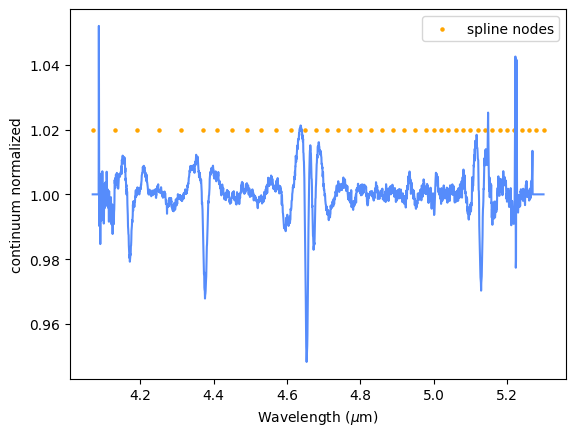

In [7]:
combined_contnorm_spec_filename = os.path.join(utils_dir, splitbasename[0] + "_" + splitbasename[1]+ "_" + detector + "_starspec_contnorm_combined_1dspline.fits")
combined_star_func = compute_normalized_stellar_spectrum(cleaned_cal_files, utils_dir, combined_contnorm_spec_filename,
                                    mppool=mypool,targetname=simbad_name,mask_charge_transfer_radius=mask_charge_transfer_radius,
                                    ra_dec_point_sources=ra_dec_point_sources)

#############
# Plotting

plt.plot(wv_sampling,combined_star_func(wv_sampling))
wv_nodes = default.nodes_dict[grating][detector] # When nothing is specified, the function above uses these default spline nodes
plt.scatter(wv_nodes,1.02*np.ones(wv_nodes.shape),s=5,c="orange",label="spline nodes")
plt.xlabel(r"Wavelength ($\mu$m)")
plt.ylabel("continuum normalized")
plt.legend()

fit the centroid of each dither independently using the existing default BreadsPSF.
``poly_deg_coords=1`` defines the degree of the polynomial used to fit the centroid vs wavelength. This polynomial is used to recalibrate the point cloud coordinates in subsequent steps.

The resulting polynomial coefficients are saved in files such as:
jw08063005001_02101_00001_nrs2_cal_fitspsf_breadspsf_init_poly_centroid_IWA0.00_OWA1.00.txt
-4.824321401350048152e-03 -8.842510846400657154e-02
-8.756009163783950305e-03 -5.829449926890867273e-02



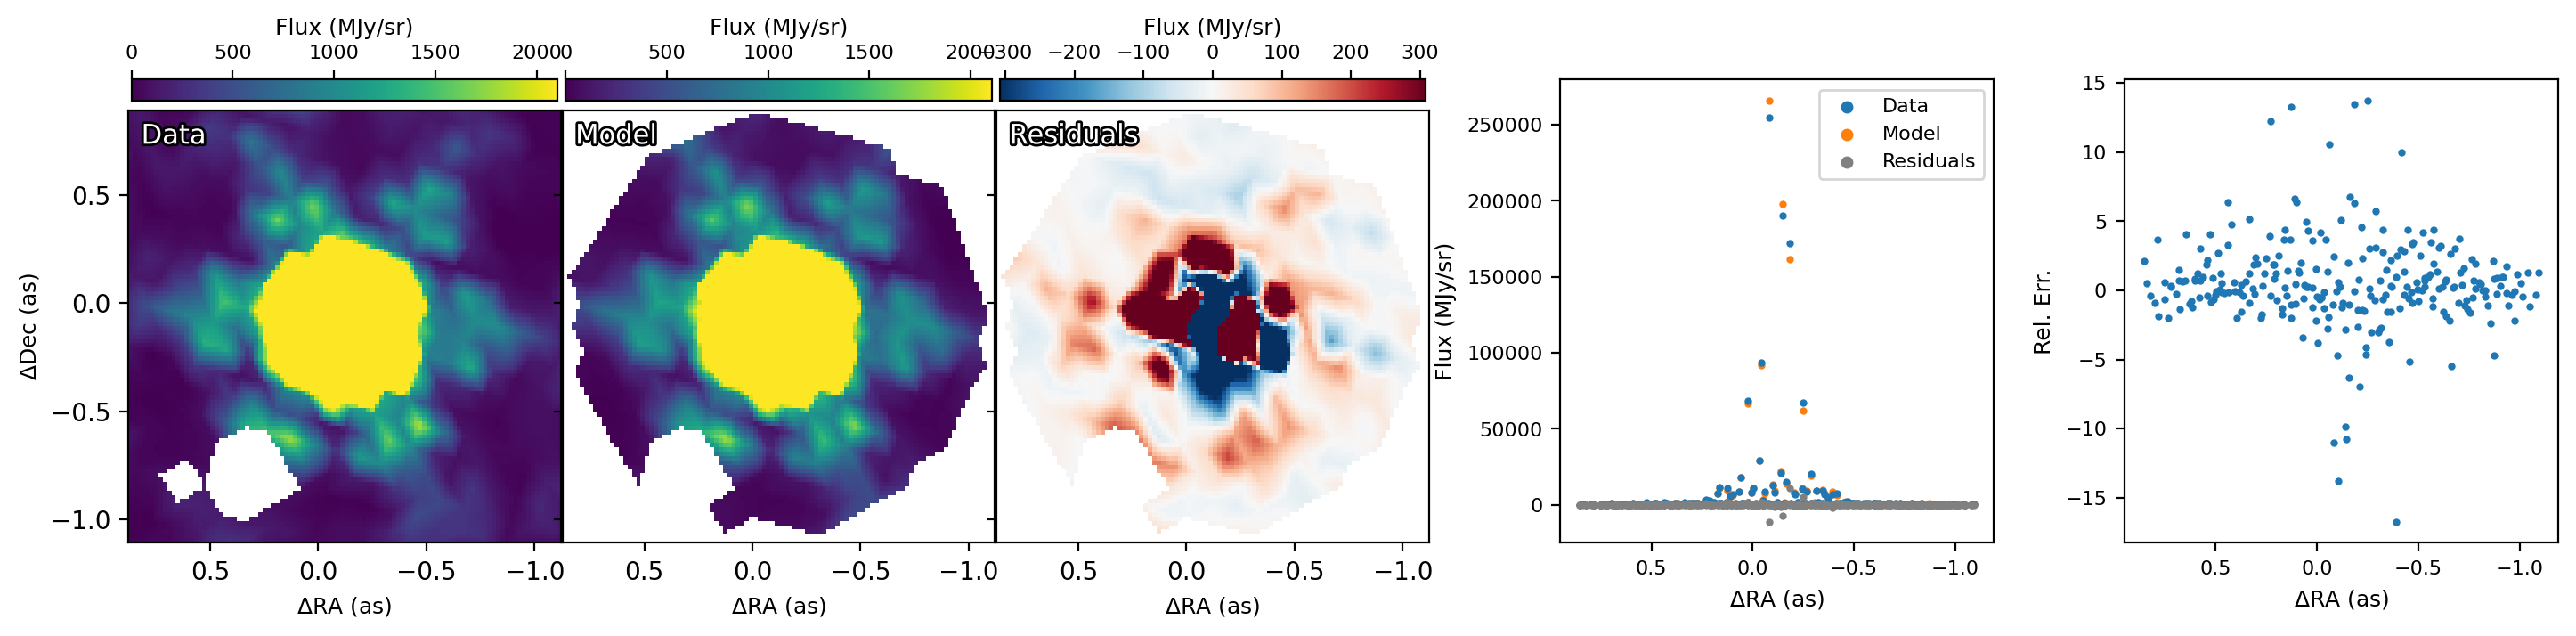

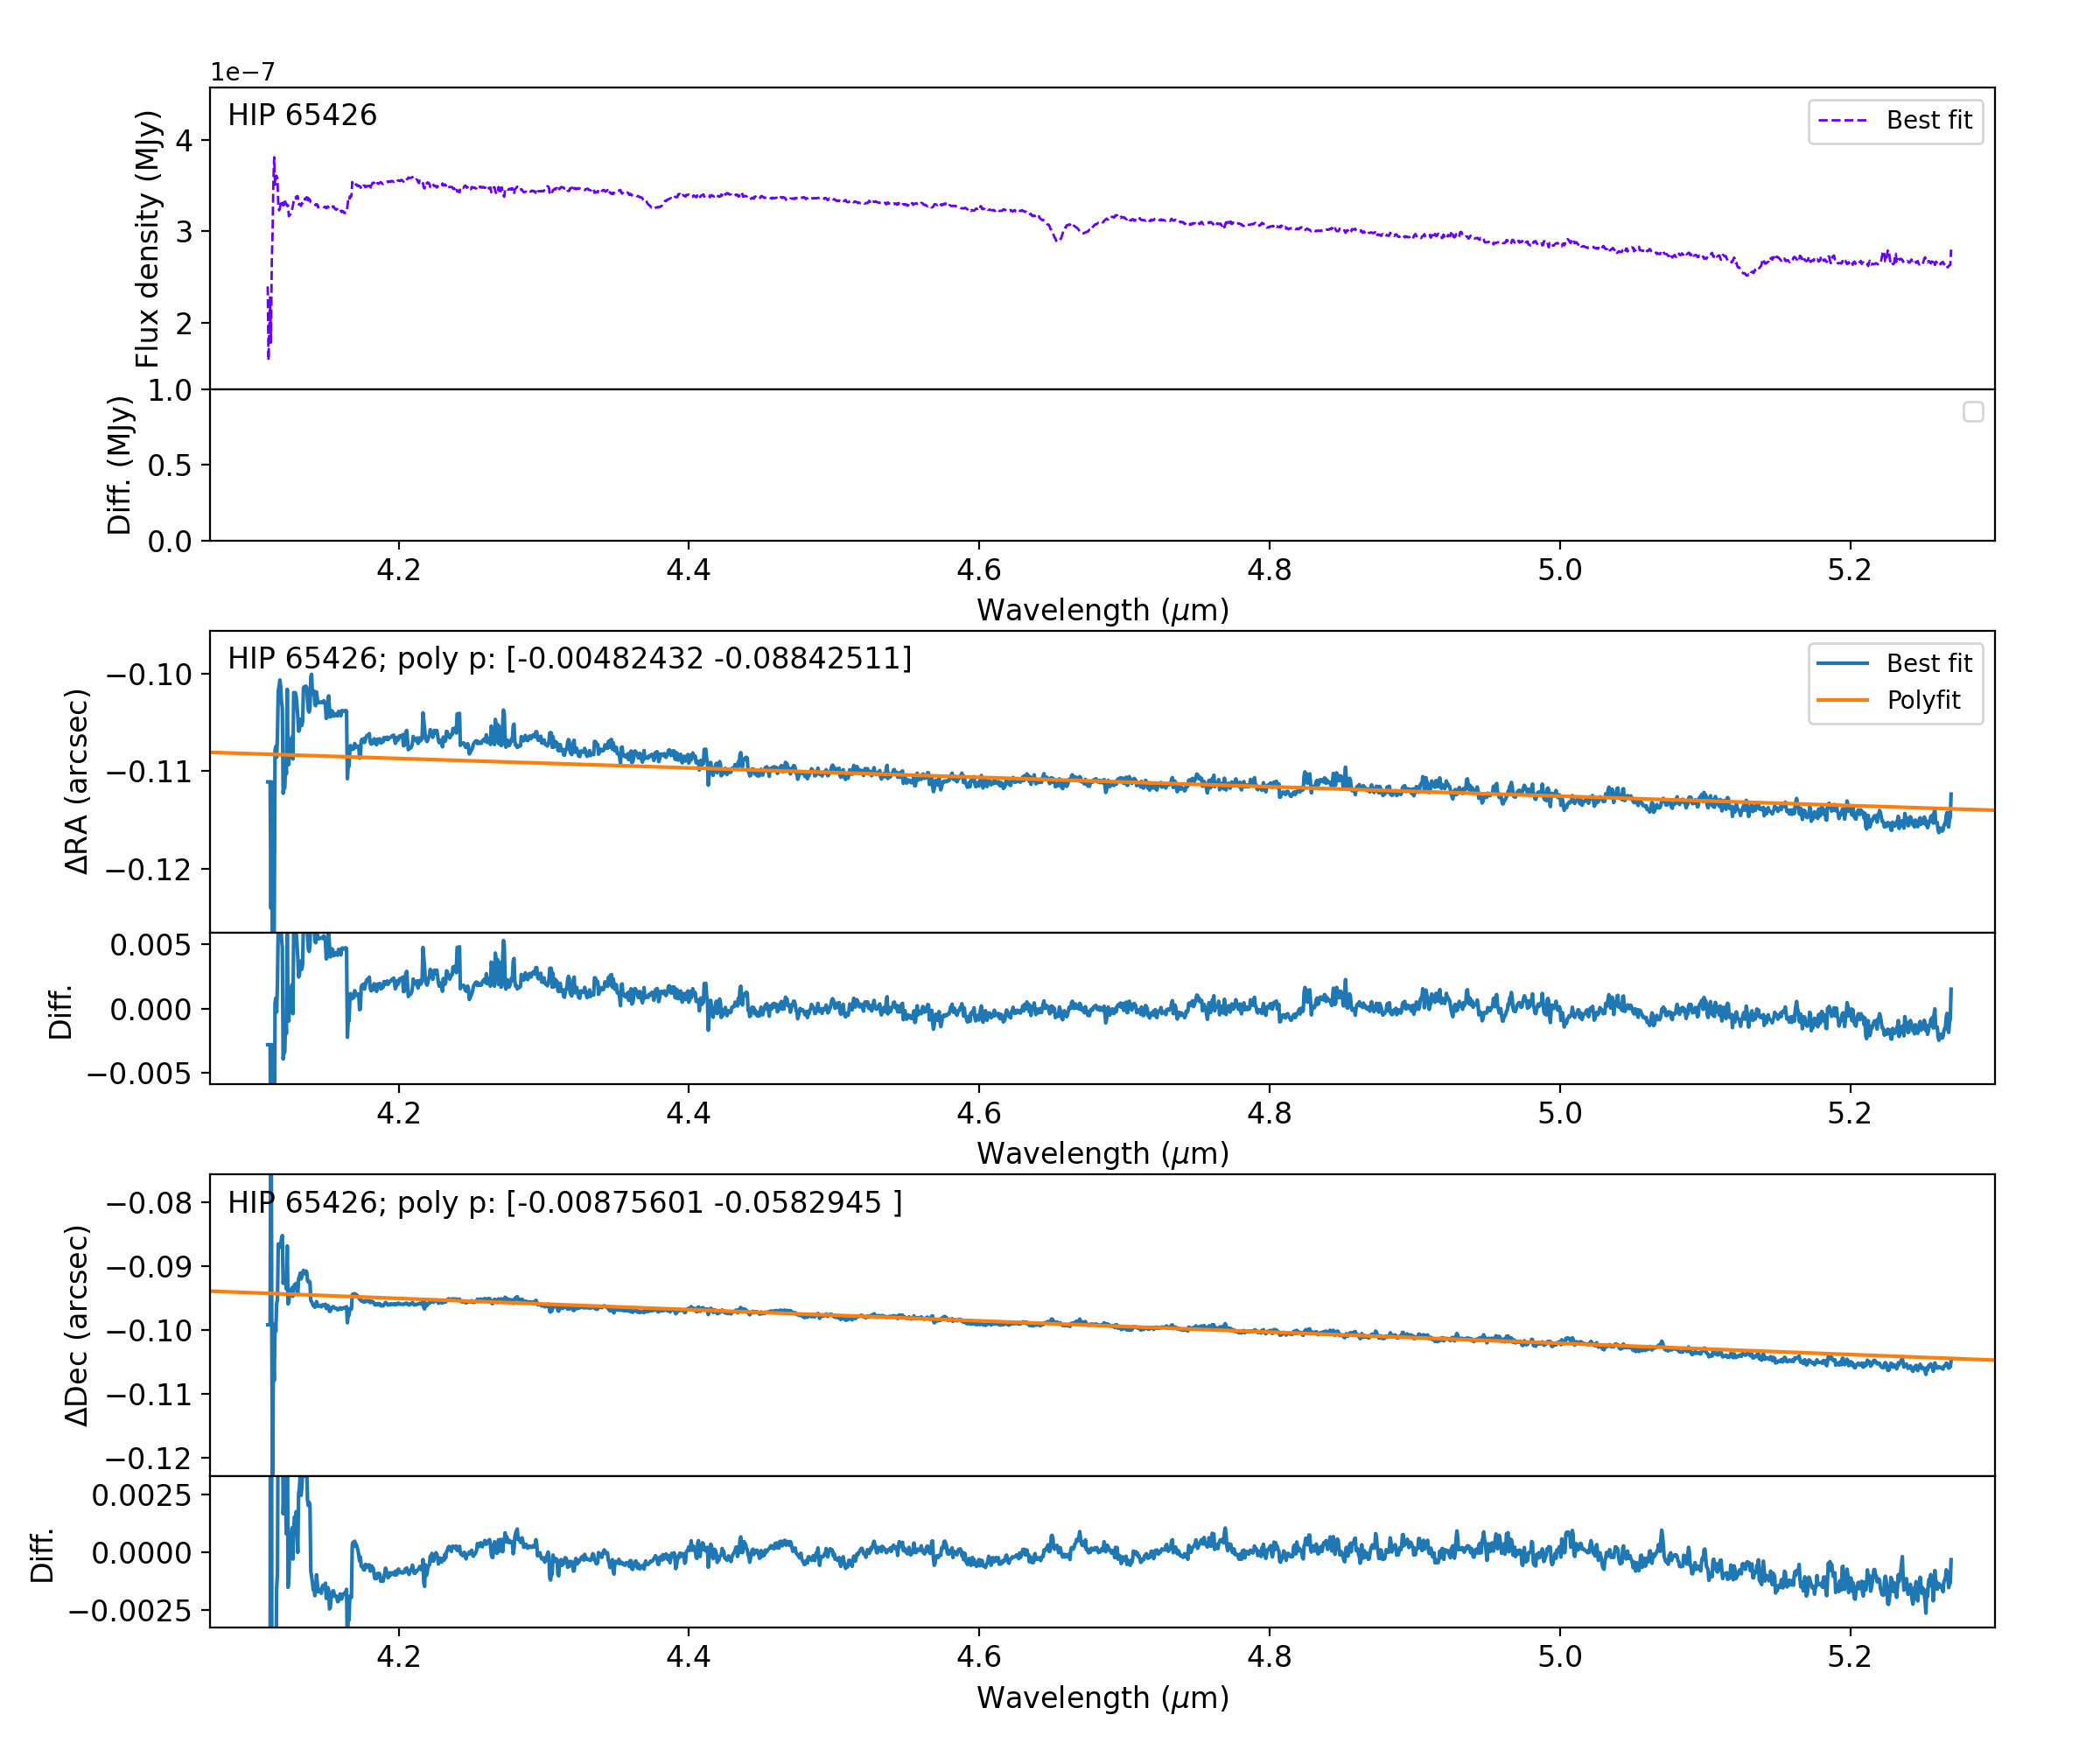

In [9]:
centroid_suffix_init = "_fitspsf_breadspsf_init"

recenter_coordinates_per_frame_nirspec(cleaned_cal_files, utils_dir, combined_contnorm_spec_filename,
                                       centroid_suffix_init,
                                       mppool=mypool,
                                       overwrite=False,
                                       targetname=simbad_name,
                                       stis_spectrum=None,
                                       use_breadspsf=True,
                                       IWA=IWA_cen, OWA=OWA_cen,
                                       poly_deg_coords=1,
                                       plot_combined=True,
                                       mask_charge_transfer_radius=mask_charge_transfer_radius,
                                       ra_dec_point_sources=ra_dec_point_sources,
                                       wv_min=wv_min_cen, wv_max=wv_max_cen,)

#############
# Plotting

print("The resulting polynomial coefficients are saved in files such as:")
print("jw08063005001_02101_00001_nrs2_cal_fitspsf_breadspsf_init_poly_centroid_IWA0.00_OWA1.00.txt")
with open(os.path.join(utils_dir,"jw08063006001_02101_00001_nrs2_cal_fitspsf_breadspsf_init_poly_centroid_IWA0.00_OWA1.00.txt")) as f:
    print(f.read())

# For the previews, look for PNGs like these in the utils folder:
from IPython.display import Image, display
display(Image(filename=os.path.join(utils_dir,"jw08063006001_02101_00001_nrs2_cal_fitspsf_breadspsf_init2d_plot.png")))
display(Image(filename=os.path.join(utils_dir,"jw08063006001_02101_00001_nrs2_cal_fitspsf_breadspsf_init_results.png")))



First, fit the 3d spline model to the combined point cloud.
Then, create a **BreadsPSF** from it that can be used like a stpsf.

``plot_3dspline_residuals`` can be used to plot PNGs of the residuals per file and per slice for all files/slices but this takes a little while.

/tmp/ipykernel_2666639/3161275859.py:25: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(spline3d_paras[k,l,spline3d_paras.shape[2]//2,:,:]),origin="lower")
/tmp/ipykernel_2666639/3161275859.py:29: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(breadspsf[breadspsf.shape[0]//2,:,:]),origin="lower")


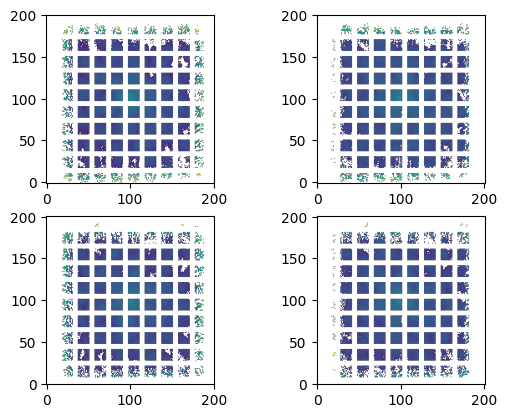

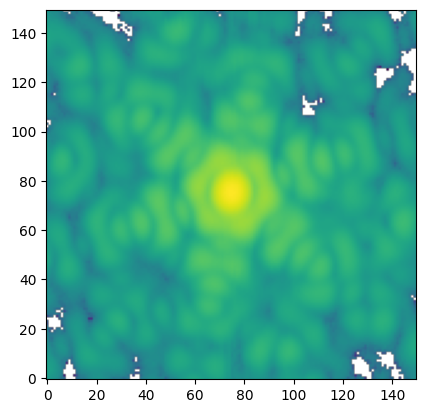

In [10]:
spline3d_suffix = "_init"
breadsPSF_basename_init = targetname+"_"+program+"_"+obsnum+"_"+grating+"_"+detector+spline3d_suffix+".fits"

combdataobj = compute_3dsplines(cleaned_cal_files, utils_dir, simbad_name,combined_contnorm_spec_filename,
                                coords_filename_filter = centroid_suffix_init+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                                spline3d_suffix = spline3d_suffix,numthreads=numthreads,centroid_per_frame=True,
                                save_pickle=True, load_pickle=True,mask_charge_transfer_radius=None,
                                overwrite=False)
# plot_3dspline_residuals(combdataobj,overwrite=False)

spline3d_filename_init = combdataobj.default_filenames["compute_starsubtraction_3dspline"]
breadspsf,breadspsf_err = create_BreadsPSF(spline3d_filename_init, x_vec, y_vec, wv_sampling,stis_spectrum=None,
                                           basename=breadsPSF_basename_init,numthreads=numthreads,overwrite=False)

#############
# Plotting

# Best fit spline parameters
plt.figure()
with fits.open(spline3d_filename_init) as hdulist:
    spline3d_paras = hdulist["SPLINE_PARAS0"].data
for k in range(2):
    for l in range(2):
        plt.subplot(2,2,k*2+l+1)
        plt.imshow(np.log10(spline3d_paras[k,l,spline3d_paras.shape[2]//2,:,:]),origin="lower")

# Computed breadsPSF from the 3d spline model
plt.figure()
plt.imshow(np.log10(breadspsf[breadspsf.shape[0]//2,:,:]),origin="lower")

Refit the centroid of each dither independently, but this time with the breadsPSF created from the data itself. See the previous iteration for previews.

In [11]:
centroid_suffix = "_fitspsf_breadspsf"
recenter_coordinates_per_frame_nirspec(cleaned_cal_files, utils_dir, combined_contnorm_spec_filename,
                                       centroid_suffix,
                                       mppool=mypool,
                                       overwrite=False,
                                       targetname=simbad_name,
                                       stis_spectrum=None,
                                       use_breadspsf=breadsPSF_basename_init,
                                       poly_deg_coords=1,
                                       IWA=IWA_cen, OWA=OWA_cen,
                                       plot_combined=True,
                                       mask_charge_transfer_radius=mask_charge_transfer_radius,
                                       wv_min=wv_min_cen, wv_max=wv_max_cen,)

Redo the 3d spline fit and breadsPSF with revised centroid calibration. See the previous iteration for previews.

In [12]:
spline3d_suffix = ""

combdataobj = compute_3dsplines(cleaned_cal_files, utils_dir, simbad_name,combined_contnorm_spec_filename,
                                coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                                spline3d_suffix = spline3d_suffix,numthreads=numthreads,centroid_per_frame=True,
                                save_pickle=True, load_pickle=True,mask_charge_transfer_radius=None)
plot_3dspline_residuals(combdataobj,overwrite=False)

breadsPSF_basename = targetname+"_"+program+"_"+obsnum+"_"+grating+"_"+detector+spline3d_suffix+".fits"
spline3d_filename = combdataobj.default_filenames["compute_starsubtraction_3dspline"]
breadspsf,breadspsf_err = create_BreadsPSF(spline3d_filename, x_vec, y_vec, wv_sampling,stis_spectrum=None,
                                           basename=breadsPSF_basename,numthreads=numthreads)

## S/N maps

S/N maps are computed by fitting for a joint forward model (planet + star) projected directly to the detector images. The starlight is model with a combination of 1d splines (row by row) to model the continuum variations and the empirical continuum normalized spectrum of the star derived previously. Each exposure is fitting individually first, and they can be combined later.

/stow/jruffio/data/JWST/nirspec/HIP_65426/obsnum06_8063/G395H_stage2_cleaned/jw08063006001_02101_00001_nrs2_cal.fits
/stow/jruffio/data/JWST/nirspec/HIP_65426/obsnum06_8063/G395H_stage2_cleaned/jw08063006001_02101_00002_nrs2_cal.fits


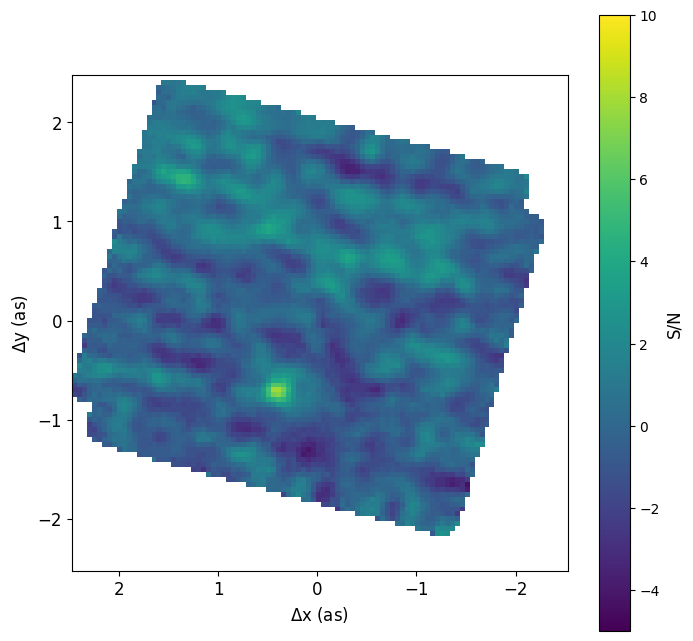

In [19]:
photfilter_name = default.photfilter_name_dict[grating][detector]
BREADS_DATA_ENV = os.getenv('BREADS_DATA')
photfilter_filename = os.path.join(BREADS_DATA_ENV, "filters", "JWST_NIRCam." + photfilter_name + ".dat")
model_grid_h5py = os.path.join(BREADS_DATA_ENV, "model_grid", "BT-Settlchris_0.5-6.0um_Teff500_1600_logg3.5_5.0_NIRSpec.hdf5")
teff, logg, vsini= 1200, 4.5, 0.0
grid_paras =(teff, logg, vsini)

suffix = "snr_map"
# Define grid of ra/dec to compute SNR map
ra_vec_snr = np.arange(-2.5, 2.5, 0.05)
dec_vec_snr = np.arange(-2.5, 2.5, 0.05)

compute_snr_grid(cleaned_cal_files[0:3], utils_dir, os.path.join(out_dir,"snr_map"),
                 combined_contnorm_spec_filename,
                 centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                 model_grid_h5py,grid_paras,photfilter_filename,N_KL=3,
                 suffix=suffix, contnorm_suffix=None,
                 x_vec=ra_vec_snr, y_vec=dec_vec_snr, rv_vec=np.array([star_rv]),
                 mask_charge_transfer_radius = mask_charge_transfer_radius,ra_dec_point_sources=ra_dec_point_sources,
                 mppool=mypool,
                 overwrite = False,
                 targetname=simbad_name,
                 use_stpsf=False, use_breadspsf=True)

################################
## Plot combined S/N map

splitbasename = os.path.basename(cleaned_cal_files[0]).split("_")
snr_grid_filename = os.path.join(out_dir,"snr_map",splitbasename[0] + "_" + splitbasename[1]+ "_" + detector+ "_" + grating+"_"+suffix + "_combined.fits")
## replace by the following lines to look at individual exposure
# filename = cleaned_cal_files[0]
# snr_grid_filename = os.path.join(out_dir,"snr_map", os.path.basename(filename).replace(".fits", "_"+ suffix + ".fits"))

with fits.open(snr_grid_filename) as hdulist:
    _priheader = hdulist[0].header
    _extheader = hdulist[1].header
    flux_arr = hdulist['flux_arr'].data
    fluxerr_arr = hdulist['fluxerr_arr'].data
    log_prob = hdulist['log_prob'].data
    x_vec = hdulist['x_vec'].data
    y_vec = hdulist['y_vec'].data
    rv_vec = hdulist['rv_vec'].data
    wv_nodes = hdulist['wv_nodes'].data
    _breads_header = hdulist['BREADS'].data


fig0 = plt.figure(figsize=(8,8))
dx, dy = x_vec[1] - x_vec[0], y_vec[1] - y_vec[0]
extent = [x_vec[0] - dx / 2., x_vec[-1] + dx / 2., y_vec[0] - dy / 2., y_vec[-1] + dy / 2.]
rv0_id = len(rv_vec)//2
fontsize=12
ax = plt.gca()
im_handle = ax.imshow(flux_arr[rv0_id,:,:]/fluxerr_arr[rv0_id,:,:], origin="lower", cmap="viridis", extent=extent, vmin=-5, vmax=10)
cbar = plt.colorbar(im_handle, ax=ax)
cbar.set_label("S/N", fontsize=fontsize)
ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel(r"$\Delta$x (as)", fontsize=fontsize)
ax.set_ylabel(r"$\Delta$y (as)", fontsize=fontsize)
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)

## Relative astrometry

In order to get the astrometry of a planet, we can run the same code as the SNR map, but on a very small stamp around the planet.

``fix_fitting_region_around_xy=(ra_planets[pl] / 1000.,dec_planets[pl] / 1000.)`` forces the fitting region to be fixed around the planet. This avoids discontinuities in the probability map, which would occur otherwise as the fitting region would move around following the planet model location; ie, the number of data points being used to define the chi2 would change depending on the assumed planet location.

<>:66: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:66: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2666639/210671751.py:66: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$\propto$ Probability density")
/tmp/ipykernel_2666639/210671751.py:71: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$\propto$ Probability density")


/stow/jruffio/data/JWST/nirspec/HIP_65426/obsnum06_8063/G395H_stage2_cleaned/jw08063006001_02101_00001_nrs2_cal.fits
/stow/jruffio/data/JWST/nirspec/HIP_65426/obsnum06_8063/G395H_stage2_cleaned/jw08063006001_02101_00002_nrs2_cal.fits


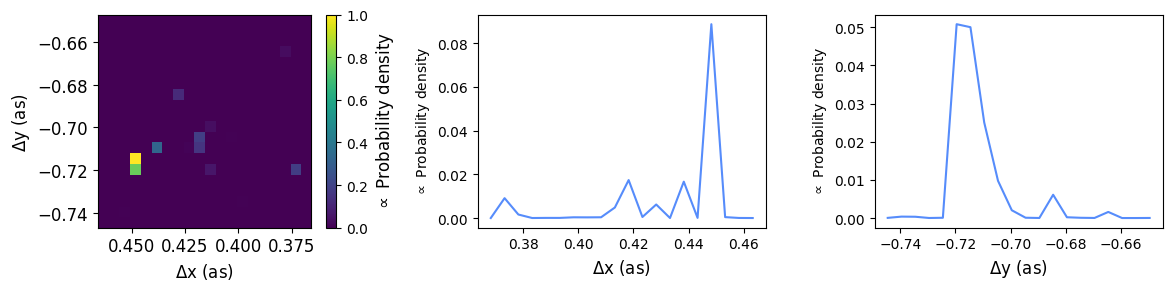

In [36]:
pl="b"
suffix = "astrometry_"+pl
# Define grid of ra/dec to compute log prob map
ra_vec_astro = np.arange(-0.05, 0.05, 0.005)+ra_planets[pl]/1000.
dec_vec_astro = np.arange(-0.05, 0.05, 0.005)+dec_planets[pl]/1000.

compute_snr_grid(cleaned_cal_files[0:2], utils_dir, os.path.join(out_dir,"astrometry"),
                 combined_contnorm_spec_filename,
                 centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                 model_grid_h5py,grid_paras,photfilter_filename,N_KL=0,
                 suffix=suffix, contnorm_suffix=None,
                 x_vec=ra_vec_astro, y_vec=dec_vec_astro, rv_vec=np.array([star_rv]),
                 mask_charge_transfer_radius = mask_charge_transfer_radius,ra_dec_point_sources=ra_dec_point_sources,
                 fix_fitting_region_around_xy=(ra_planets[pl] / 1000.,dec_planets[pl] / 1000.), # This is the important line for fitting astrometry
                 mppool=mypool,
                 overwrite = False,
                 targetname=simbad_name,
                 use_stpsf=False, use_breadspsf=True)


################################
## Plot combined log likelihood map and posteriors for astrometry

splitbasename = os.path.basename(cleaned_cal_files[0]).split("_")
snr_grid_filename = os.path.join(out_dir,"astrometry",splitbasename[0] + "_" + splitbasename[1]+ "_" + detector+ "_" + grating+"_"+suffix + "_combined.fits")
## replace by the following lines to look at individual exposure
# filename = cleaned_cal_files[0]
# snr_grid_filename = os.path.join(out_dir,"astrometry_"+pl, os.path.basename(filename).replace(".fits", "_"+ suffix + ".fits"))

with fits.open(snr_grid_filename) as hdulist:
    _priheader = hdulist[0].header
    _extheader = hdulist[1].header
    flux_arr = hdulist['flux_arr'].data
    fluxerr_arr = hdulist['fluxerr_arr'].data
    log_prob = hdulist['log_prob'].data
    x_vec = hdulist['x_vec'].data
    y_vec = hdulist['y_vec'].data
    rv_vec = hdulist['rv_vec'].data
    wv_nodes = hdulist['wv_nodes'].data
    _breads_header = hdulist['BREADS'].data

dx, dy = x_vec[1] - x_vec[0], y_vec[1] - y_vec[0]
extent = [x_vec[0] - dx / 2., x_vec[-1] + dx / 2., y_vec[0] - dy / 2., y_vec[-1] + dy / 2.]
rv0_id = len(rv_vec)//2
fontsize=12

# Take exponential of log probability to get the posterior
posterior = np.exp(log_prob[rv0_id,:,:]-np.nanmax(log_prob[rv0_id,:,:]))

fig0 = plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
ax = plt.gca()
im_handle = ax.imshow(posterior, origin="lower", cmap="viridis", extent=extent, vmin=0, vmax=1)
cbar = plt.colorbar(im_handle, ax=ax)
cbar.set_label(r"$\propto$ Probability density", fontsize=fontsize)
ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel(r"$\Delta$x (as)", fontsize=fontsize)
ax.set_ylabel(r"$\Delta$y (as)", fontsize=fontsize)
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)

plt.subplot(1,3,2)
plt.plot(x_vec,np.nanmean(posterior,axis=0))
plt.xlabel(r"$\Delta$x (as)", fontsize=fontsize)
plt.ylabel("$\propto$ Probability density")

plt.subplot(1,3,3)
plt.plot(y_vec,np.nanmean(posterior,axis=1))
plt.xlabel(r"$\Delta$y (as)", fontsize=fontsize)
plt.ylabel("$\propto$ Probability density")

plt.tight_layout()


## Spectral extraction (Raw PSF)

There are two main wrappers for the spectral extraction, ``cube_extraction()`` and ``extract_spectrum()``, which we illustrate below.
``cube_extraction`` in essence is performing spectral extraction on a regular grid a positions and wavelength by fitting a model PSF (STPSF with ``use_stpsf=True`` or breadsPSF with ``use_breadspsf=True``) and retrieving the best fit scaling factor (ie, the flux of a point source at this location/wavelength).
The model PSF is fit to the data in a region of size ```aper_radius``` (arcsec).
The final cubes built are saved in the ``out_dir`` directory and form the primary data product for subsequent spectral analysis.


As a reference, we will start by extracting a cube of the raw PSF, without any PSF subtraction. This will provide a way to determine the level of local starlight suppression (or systematics floor) for any of the following methods.

flux_cube.shape (2197, 80, 80)
fluxerr_cube.shape (2197, 80, 80)
x_grid.shape (80, 80)
y_grid.shape (80, 80)
wv_sampling.shape (2197,)


/tmp/ipykernel_2666639/2874163660.py:41: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(flux_cube[flux_cube.shape[0]//2,:,:]),origin="lower")


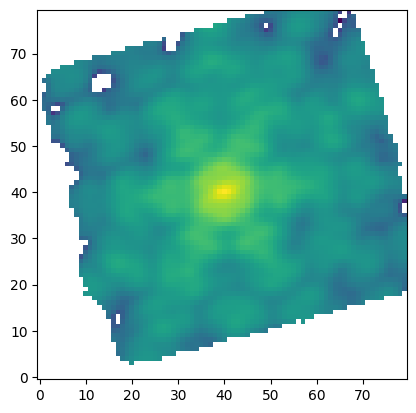

In [20]:
pl = "b"
ra_offset = ra_planets[pl] / 1000.  # ra offset in as
dec_offset = dec_planets[pl] / 1000.  # dec offset in as
xy_coords = (ra_offset,dec_offset)

cube_mode = "raw"
suffix = cube_mode
flux_cube0, fluxerr_cube0, x_grid, y_grid,wv_sampling = \
    cube_extraction(cleaned_cal_files, utils_dir, out_dir, combined_contnorm_spec_filename,
                coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                mode=cube_mode, suffix=suffix,
                x_vec=ra_vec, y_vec=dec_vec, wv_sampling=None,
                mask_charge_transfer_radius=None, ra_dec_point_sources=None,
                aper_radius=0.15,
                mppool=mypool,
                overwrite=False,
                targetname=simbad_name,
                use_stpsf=False,
                use_breadspsf=True,
                load_pickle=True,
                save_pickle=True,
                ifucoords=False)

#############
# Plotting

cube_filename = os.path.join(out_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_" + grating + "_" + suffix + "_cube.fits")
with fits.open(cube_filename) as hdulist:
    flux_cube    = hdulist['FLUX'].data # MJy
    fluxerr_cube = hdulist['FLUXERR'].data # MJy
    x_grid       = hdulist['X'].data # arcsec
    y_grid       = hdulist['Y'].data # arcsec
    wv_sampling  = hdulist['WAVE'].data # microns

print("flux_cube.shape",flux_cube.shape)
print("fluxerr_cube.shape",fluxerr_cube.shape)
print("x_grid.shape",x_grid.shape)
print("y_grid.shape",y_grid.shape)
print("wv_sampling.shape",wv_sampling.shape)

plt.imshow(np.log10(flux_cube[flux_cube.shape[0]//2,:,:]),origin="lower")

In the following cell, we illustrate how to use the wrapper ``extract_spectrum()`` to make fits files with companion spectra. It is not needed to use this function. Manually extracting the spectra directly from the BREADS cubes is encouraged if one desires more control over the extraction.

See ``os.path.join(out_dir,"HIP_65426_obsnum05_nrs2_raw_1dspectrum_1dspec.html")`` and ``os.path.join(out_dir,"HIP_65426_obsnum05_nrs2_raw_1dspectrum_im.png")`` for previews.

/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


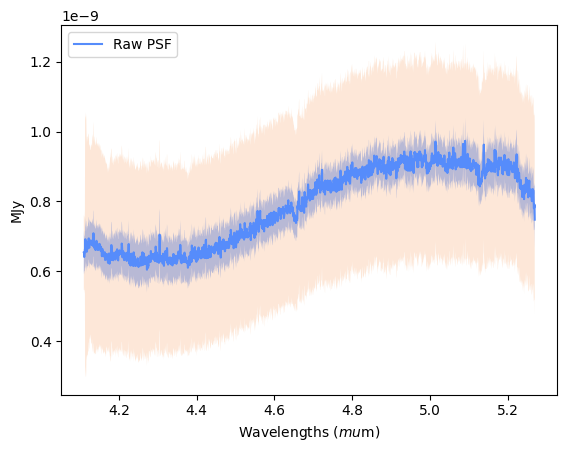

In [24]:
out_filename = os.path.join(out_dir, f"{targetname}_{obsnum}_{detector}_{suffix}_1dspectrum.fits")

extract_spectrum(cube_filename,out_filename,xy_coords)

# --- Read FITS output for this planet ---
with fits.open(out_filename) as hdulist_in:
    wv_sampling         = hdulist_in['WAVE'].data # microns
    spectrum            = hdulist_in['FLUX_MJy'].data # MJy
    err                 = hdulist_in['ERR_MJy'].data # MJy, error propagation of stcal photon noise and read noise
    speckle_std         = hdulist_in['STD_MJy'].data # MJy, empirical error from stddev of the speckles
    speckles            = hdulist_in['SPECKLES'].data # MJy
    spectrum_Flambda    = hdulist_in['FLUX_FLAM'].data # W/m2/um-1
    err_Flambda         = hdulist_in['ERR_FLAM'].data # W/m2/um-1
    speckle_std_Flambda = hdulist_in['STD_FLAM'].data # W/m2/um-1
    speckles_Flambda    = hdulist_in['SPECKLES_FLAM'].data # W/m2/um-1

    # Header keywords were written to the primary HDU (index 0)
    label = hdulist_in[0].header['LABEL']
    x     = hdulist_in[0].header['XCOORD']
    y     = hdulist_in[0].header['YCOORD']

plt.plot(wv_sampling,spectrum,label="Raw PSF")
plt.fill_between(wv_sampling,spectrum-err,spectrum+err,alpha=0.5)
plt.fill_between(wv_sampling,spectrum-speckle_std,spectrum+speckle_std,alpha=0.2)
plt.xlabel("Wavelengths ($mu$m)")
plt.ylabel("MJy")
plt.legend()

## Interpolating the 2D point cloud
When setting ``save_pickle=True``, the function will also pickle the combined data object, which can plotted as follow for example. In this case, the data object has been interpolated on a regular wavelength grid already. This cell is only to illustrate the data object and the point cloud that is used inside ``cube_extraction()``.

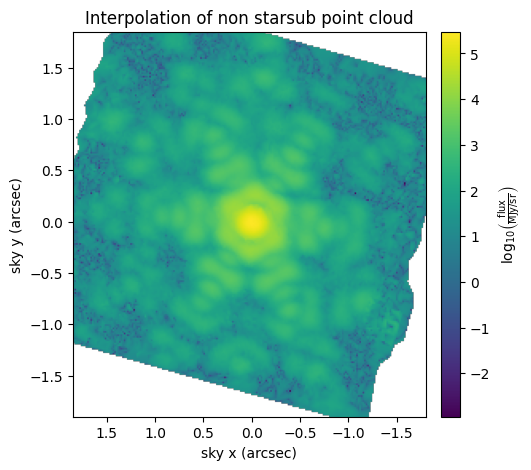

In [21]:
from breads.jwst_tools.plotting import point_cloud_interpolator_2d
from breads.instruments.jwstnirspec_multiple_cals import JWSTNirspec_multiple_cals

pickle_suffix = "_" + suffix + "_sky_regwvs"
pickle_filename = os.path.join(utils_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + pickle_suffix + ".pkl")

combdataobj = JWSTNirspec_multiple_cals.load(pickle_filename)
wv0=np.nanmedian(wv_sampling)

# Create the interpolator object of the point cloud
pointcloud_interp = point_cloud_interpolator_2d(combdataobj.x,
                                                combdataobj.y,
                                                combdataobj.wv_sampling,
                                                combdataobj.data,
                                                combdataobj.bad_pixels,
                                                wv0)

dramin, dramax, ddecmin, ddecmax = np.min(ra_vec),np.max(ra_vec),np.min(dec_vec),np.max(dec_vec)
extent=[dramin, dramax, ddecmin, ddecmax]

N = 240
ra_vec = np.linspace(dramin,dramax,N)
dec_vec = np.linspace(ddecmin,ddecmax,N)
inp = np.meshgrid(ra_vec,dec_vec)

# Evaluate the interpolator object on the grid
out = pointcloud_interp(inp[0],inp[1])

fig =plt.figure(figsize=(5,5))
im = plt.imshow(np.log10(abs(out)),origin='lower',extent=extent,aspect='auto')

plt.xlim([dramax-.1,dramin+.2])
plt.ylim([ddecmin+.1,ddecmax-.1])
cbar = fig.colorbar(im, fraction=0.05, pad=0.04)
cbar.set_label(r'log$_{10} \left(\frac{\mathrm{flux}}{\mathrm{MJy/sr}}\right)$')
plt.xlabel('sky x (arcsec)')
plt.ylabel('sky y (arcsec)')
plt.title('Interpolation of non starsub point cloud')
plt.show()

## Using sky or ifu coordinates

It is also possible to convert the data object to the coordinate system of the IFU using ``combdataobj.set_coords2ifu()``.

See also:

- ``combdataobj.set_coords2ifu()``
- ``ifux, ifuy = self.get_ifu_coords()``
- ``combdataobj.set_coords2sky()``
- ``dra, ddec = self.get_sky_coords()``

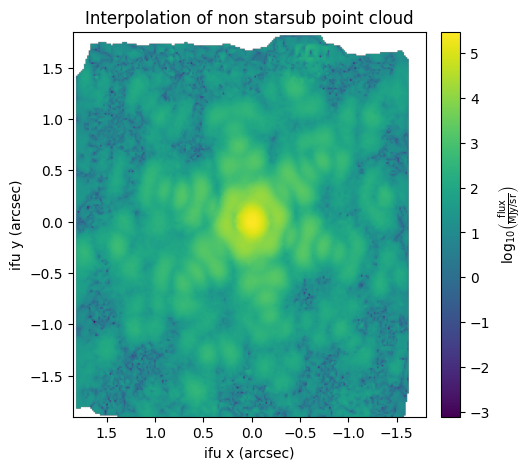

In [22]:
combdataobj.set_coords2ifu()

# Create the interpolator object of the point cloud
pointcloud_interp = point_cloud_interpolator_2d(combdataobj.x,
                                                combdataobj.y,
                                                combdataobj.wv_sampling,
                                                combdataobj.data,
                                                combdataobj.bad_pixels,
                                                wv0)

dramin, dramax, ddecmin, ddecmax = np.min(ra_vec),np.max(ra_vec),np.min(dec_vec),np.max(dec_vec)
extent=[dramin, dramax, ddecmin, ddecmax]

N = 240
ra_vec = np.linspace(dramin,dramax,N)
dec_vec = np.linspace(ddecmin,ddecmax,N)
inp = np.meshgrid(ra_vec,dec_vec)

# Evaluate the interpolator object on the grid
out = pointcloud_interp(inp[0],inp[1])

fig =plt.figure(figsize=(5,5))
im = plt.imshow(np.log10(abs(out)),origin='lower',extent=extent,aspect='auto')

plt.xlim([dramax-.1,dramin+.2])
plt.ylim([ddecmin+.1,ddecmax-.1])
cbar = fig.colorbar(im, fraction=0.05, pad=0.04)
cbar.set_label(r'log$_{10} \left(\frac{\mathrm{flux}}{\mathrm{MJy/sr}}\right)$')
plt.xlabel('ifu x (arcsec)')
plt.ylabel('ifu y (arcsec)')
plt.title('Interpolation of non starsub point cloud')
plt.show()

## High-pass filtered spectrum (1d spline)

This is the spectral extraction technique used in most JWST NIRSpec papers so far.

/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


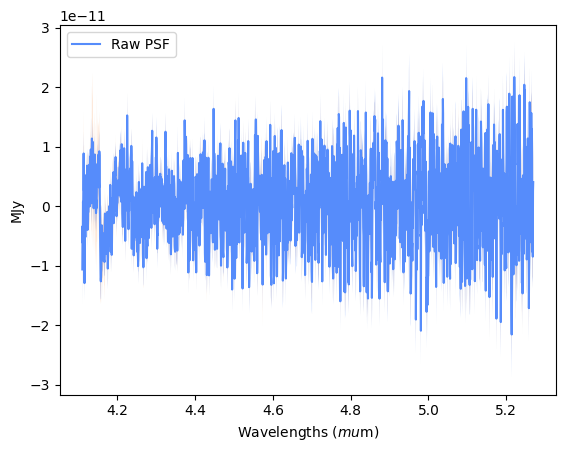

In [26]:
cube_mode = "1dspline"
suffix = cube_mode
flux_cube1, fluxerr_cube1, x_grid, y_grid,wv_sampling = \
    cube_extraction(cleaned_cal_files, utils_dir, out_dir, combined_contnorm_spec_filename,
                                coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                mode=cube_mode, suffix=suffix,contnorm_suffix = None,
                x_vec=ra_vec, y_vec=dec_vec, wv_sampling=None,
                mask_charge_transfer_radius=None, ra_dec_point_sources=None,
                aper_radius=0.15,
                mppool=mypool,
                overwrite=False,
                targetname=simbad_name,
                use_stpsf=False,
                use_breadspsf=True,
                load_pickle=True,
                save_pickle=True,
                ifucoords=False)

cube_filename = os.path.join(out_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_" + grating + "_" + suffix + "_cube.fits")
out_filename = os.path.join(out_dir, f"{targetname}_{obsnum}_{detector}_{suffix}_1dspectrum.fits")
extract_spectrum(cube_filename,out_filename,xy_coords)

#############
# Plotting

# --- Read FITS output for this planet ---
with fits.open(out_filename) as hdulist_in:
    wv_sampling         = hdulist_in['WAVE'].data # microns
    spectrum            = hdulist_in['FLUX_MJy'].data # MJy
    err                 = hdulist_in['ERR_MJy'].data # MJy, error propagation of stcal photon noise and read noise
    speckle_std         = hdulist_in['STD_MJy'].data # MJy, empirical error from stddev of the speckles
    speckles            = hdulist_in['SPECKLES'].data # MJy
    spectrum_Flambda    = hdulist_in['FLUX_FLAM'].data # W/m2/um-1
    err_Flambda         = hdulist_in['ERR_FLAM'].data # W/m2/um-1
    speckle_std_Flambda = hdulist_in['STD_FLAM'].data # W/m2/um-1
    speckles_Flambda    = hdulist_in['SPECKLES_FLAM'].data # W/m2/um-1

plt.plot(wv_sampling,spectrum,label="Raw PSF")
plt.fill_between(wv_sampling,spectrum-err,spectrum+err,alpha=0.5)
plt.fill_between(wv_sampling,spectrum-speckle_std,spectrum+speckle_std,alpha=0.2)
plt.xlabel("Wavelengths ($mu$m)")
plt.ylabel("MJy")
plt.legend()

## High-pass filtered spectrum (1d spline with prior)

In development.

In [ ]:
##############
## Fewer wavelength nodes
cube_mode = "1dspline"
suffix = "1dspline_sparser"
contnorm_suffix = suffix
contnorm_sparser_filename = os.path.join(utils_dir, splitbasename[0] + "_" + splitbasename[1]+ "_" + detector + f"_starspec_contnorm_combined_{contnorm_suffix}.fits")
compute_normalized_stellar_spectrum(cleaned_cal_files, utils_dir, contnorm_sparser_filename,
                                coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                                    mppool=mypool,targetname=simbad_name,mask_charge_transfer_radius=mask_charge_transfer_radius,
                                    ra_dec_point_sources=ra_dec_point_sources,
                                    wv_nodes=default.nodes_sparser_dict[grating][detector],suffix=contnorm_suffix)

flux_cube2, fluxerr_cube2, x_grid, y_grid,wv_sampling = \
    cube_extraction(cleaned_cal_files, utils_dir, out_dir, contnorm_sparser_filename,
                                coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                mode=cube_mode, suffix=suffix,contnorm_suffix=contnorm_suffix,
                x_vec=ra_vec, y_vec=dec_vec, wv_sampling=None,
                mask_charge_transfer_radius=None, ra_dec_point_sources=None,
                aper_radius=0.15,
                mppool=mypool,
                overwrite=False,
                targetname=simbad_name,
                use_stpsf=False,
                use_breadspsf=True,
                load_pickle=True,
                save_pickle=True,
                ifucoords=False)

cube_filename = os.path.join(out_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_" + grating + "_" + suffix + "_cube.fits")
out_filename = os.path.join(out_dir, f"{targetname}_{obsnum}_{detector}_{suffix}_1dspectrum.fits")
extract_spectrum(cube_filename,out_filename,xy_coords)

##############
## Fewer wavelength nodes
cube_mode = "1dspline_with_prior"
suffix = "1dspline_sparser_with_prior"
contnorm_suffix = suffix
contnorm_sparser_filename = os.path.join(utils_dir, splitbasename[0] + "_" + splitbasename[1]+ "_" + detector + f"_starspec_contnorm_combined_{contnorm_suffix}.fits")
compute_normalized_stellar_spectrum(cleaned_cal_files, utils_dir, contnorm_sparser_filename,
                                coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                                    mppool=mypool,targetname=simbad_name,mask_charge_transfer_radius=mask_charge_transfer_radius,
                                    ra_dec_point_sources=ra_dec_point_sources,
                                    wv_nodes=default.nodes_sparser_dict[grating][detector],suffix=contnorm_suffix,
                                    spline3d_prior_filename = spline3d_filename)
# exit()
flux_cube3, fluxerr_cube3, x_grid, y_grid,wv_sampling = \
    cube_extraction(cleaned_cal_files, utils_dir, out_dir, contnorm_sparser_filename,
                                coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                mode=cube_mode, suffix=suffix, contnorm_suffix=contnorm_suffix,
                x_vec=ra_vec, y_vec=dec_vec, wv_sampling=None,
                mask_charge_transfer_radius=None, ra_dec_point_sources=None,
                aper_radius=0.15,
                mppool=mypool,
                overwrite=False,
                targetname=simbad_name,
                use_stpsf=False,
                use_breadspsf=True,
                load_pickle=True,
                save_pickle=True,
                ifucoords=False)

cube_filename = os.path.join(out_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_" + grating + "_" + suffix + "_cube.fits")
out_filename = os.path.join(out_dir, f"{targetname}_{obsnum}_{detector}_{suffix}_1dspectrum.fits")
extract_spectrum(cube_filename,out_filename,xy_coords)


## RDI spectral extraction

In the following three sections, we explore more classical PSF subtraction strategies to recover the planet the continuum.
This section provides an example for reference differential imaging (SDI) using the default breadsPSF, ie, the one computed from the calibration program 3399 available in the `google drive <https://drive.google.com/drive/folders/11GtRrZrg982UkZTHOvcGcV_EFKmQ3tVt?usp=sharing>`_, to be added in your ``breads_data`` directory.
In this case, the reference PSF might not be a perfect match due to wavefront error variability. However, breadsPSFs can be computed from any dataset following the model earlier in this notebook. Any breadsPSFs filename in the ``breads_data`` directory can be given as a string entry to ``RDI_use_breadspsf`` to use it instead.

/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


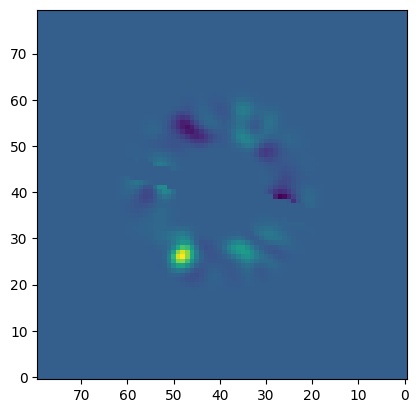

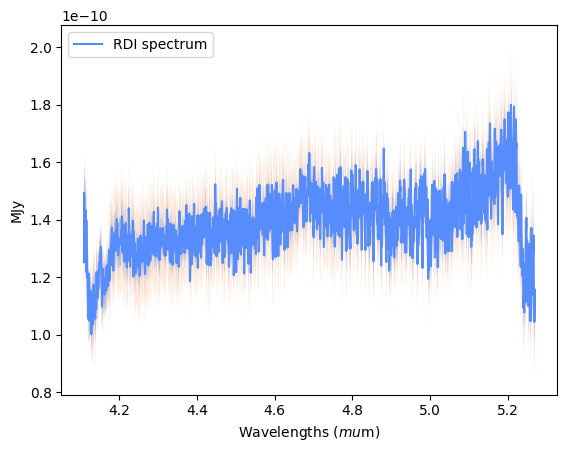

In [27]:
cube_mode = "RDI"
suffix = "RDI"
flux_cube5, fluxerr_cube5, x_grid, y_grid,wv_sampling = \
    cube_extraction(cleaned_cal_files, utils_dir, out_dir, combined_contnorm_spec_filename,
                    coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                    mode=cube_mode, suffix=suffix, contnorm_suffix=None,
                    RDI_IWA=0.6, RDI_OWA=1.0, RDI_ann_width=0.4,RDI_use_stpsf = False,RDI_use_breadspsf = True,
                x_vec=ra_vec, y_vec=dec_vec, wv_sampling=None,
                mask_charge_transfer_radius=0.15, ra_dec_point_sources=ra_dec_point_sources,
                aper_radius=0.15,
                mppool=mypool,
                overwrite=False,
                targetname=simbad_name,
                use_stpsf=False,
                use_breadspsf=True,
                load_pickle=False,
                save_pickle=True,
                ifucoords=False)

cube_filename = os.path.join(out_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_" + grating + "_" + suffix + "_cube.fits")
out_filename = os.path.join(out_dir, f"{targetname}_{obsnum}_{detector}_{suffix}_1dspectrum.fits")
extract_spectrum(cube_filename,out_filename,xy_coords)


#############
# Plotting

plt.figure()
plt.imshow(np.nansum(flux_cube5[100:flux_cube5.shape[0]-100,:,:],axis=0),origin="lower")
plt.gca().invert_xaxis()

# --- Read FITS output for this planet ---
with fits.open(out_filename) as hdulist_in:
    wv_sampling         = hdulist_in['WAVE'].data # microns
    spectrum            = hdulist_in['FLUX_MJy'].data # MJy
    err                 = hdulist_in['ERR_MJy'].data # MJy, error propagation of stcal photon noise and read noise
    speckle_std         = hdulist_in['STD_MJy'].data # MJy, empirical error from stddev of the speckles
    speckles            = hdulist_in['SPECKLES'].data # MJy
    spectrum_Flambda    = hdulist_in['FLUX_FLAM'].data # W/m2/um-1
    err_Flambda         = hdulist_in['ERR_FLAM'].data # W/m2/um-1
    speckle_std_Flambda = hdulist_in['STD_FLAM'].data # W/m2/um-1
    speckles_Flambda    = hdulist_in['SPECKLES_FLAM'].data # W/m2/um-1

plt.figure()
plt.plot(wv_sampling,spectrum,label="RDI spectrum")
plt.fill_between(wv_sampling,spectrum-err,spectrum+err,alpha=0.5)
plt.fill_between(wv_sampling,spectrum-speckle_std,spectrum+speckle_std,alpha=0.2)
plt.xlabel("Wavelengths ($mu$m)")
plt.ylabel("MJy")
plt.legend()

## ADI spectral extraction

Example of how to perform angular differential imaging (ADI).
In this case, we use the 3d spline model fitted to a different roll (the reference) to subtract the PSF in the original roll (the science).
Indeed, fitting the 3d splines yields a set of spline parameters, which are the fluxes at each node (x,y,lambda) position. The difference between two rolls is that the point cloud samples the scene differently, but we still fit the 3d splines on the same grid of nodes either way.
As a reminder, the nodes are defined in ifu coordinates and for a reference wavelength since the data is fitted after demagnification of the PSF (to remove the lambda scaling of the PSF).
Because the two rolls are from the same star, we don't need to worry about fitting for the flux of the reference PSF. We can simply take the spline parameters fitted from the reference roll, and reproject the 3d spline model onto the point cloud of the science roll. The latter can be directly subtracted from the science data, and then a normal cube extraction can be applied.

ADI can lead to significant self-subtraction of the planet signal, which needs to be corrected. This is certainly the case for HIP 65426 b at ~0.8 arcsec from the star. Calibrating the self-subtraction is addressed in a separate notebook.

/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


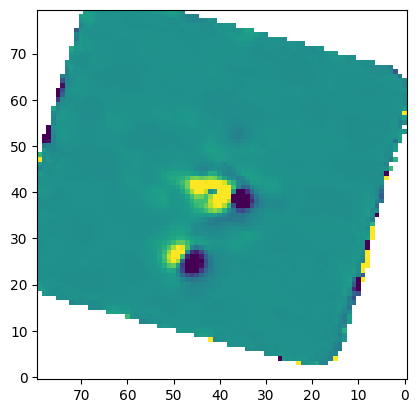

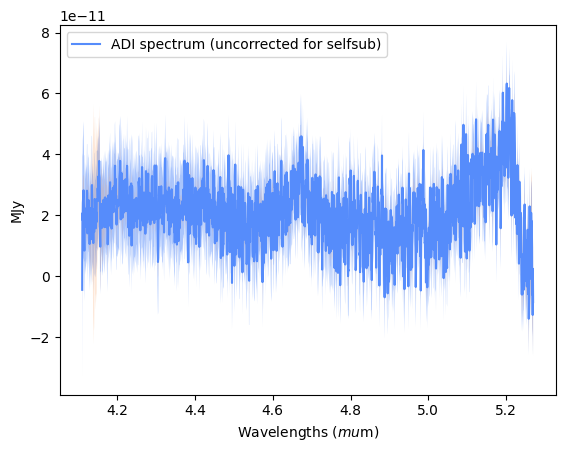

In [28]:
cube_mode = "ASDI"
suffix = "ADI"
if obsnum == "obsnum05":
    ADI_utils_dir = os.path.join(base_path, "obsnum06" + "_" + program, grating + "_utils")
    ADI_prefix = "jw08063006001_02101_" + detector
elif obsnum == "obsnum06":
    ADI_utils_dir = os.path.join(base_path, "obsnum05" + "_" + program, grating + "_utils")
    ADI_prefix = "jw08063005001_02101_" + detector
splitbasename = os.path.basename(cleaned_cal_files[0]).split("_")
starsub_3dspline_ADI_filename = os.path.join(ADI_utils_dir,ADI_prefix+"_starsub_combined_3Dspline.fits")
contnorm_3dspline_ADI_filename = os.path.join(ADI_utils_dir,ADI_prefix+"_starspec_contnorm_3Dspline.fits")
flux_cube4, fluxerr_cube4, x_grid, y_grid,wv_sampling = \
    cube_extraction(cleaned_cal_files, utils_dir, out_dir, combined_contnorm_spec_filename,
                    coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                    mode=cube_mode, suffix=suffix, contnorm_suffix=None,
                    ASDI_contnorm_3dspline_filename = contnorm_3dspline_ADI_filename, ASDI_starsub_3dspline_filename = starsub_3dspline_ADI_filename,
                x_vec=ra_vec, y_vec=dec_vec, wv_sampling=None,
                mask_charge_transfer_radius=None, ra_dec_point_sources=None,
                aper_radius=0.15,
                mppool=mypool,
                overwrite=False,
                targetname=simbad_name,
                use_stpsf=False,
                use_breadspsf=True,
                load_pickle=True,
                save_pickle=True,
                ifucoords=False)

cube_filename = os.path.join(out_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_" + grating + "_" + suffix + "_cube.fits")
out_filename = os.path.join(out_dir, f"{targetname}_{obsnum}_{detector}_{suffix}_1dspectrum.fits")
extract_spectrum(cube_filename,out_filename,xy_coords)

#############
# Plotting

plt.figure()
plt.imshow(np.nanmedian(flux_cube4[100:flux_cube4.shape[0]-100,:,:],axis=0),origin="lower")
plt.gca().invert_xaxis()
plt.clim([-5e-11,5e-11])

# --- Read FITS output for this planet ---
with fits.open(out_filename) as hdulist_in:
    wv_sampling         = hdulist_in['WAVE'].data # microns
    spectrum            = hdulist_in['FLUX_MJy'].data # MJy
    err                 = hdulist_in['ERR_MJy'].data # MJy, error propagation of stcal photon noise and read noise
    speckle_std         = hdulist_in['STD_MJy'].data # MJy, empirical error from stddev of the speckles
    speckles            = hdulist_in['SPECKLES'].data # MJy
    spectrum_Flambda    = hdulist_in['FLUX_FLAM'].data # W/m2/um-1
    err_Flambda         = hdulist_in['ERR_FLAM'].data # W/m2/um-1
    speckle_std_Flambda = hdulist_in['STD_FLAM'].data # W/m2/um-1
    speckles_Flambda    = hdulist_in['SPECKLES_FLAM'].data # W/m2/um-1

plt.figure()
plt.plot(wv_sampling,spectrum,label="ADI spectrum (uncorrected for selfsub)")
plt.fill_between(wv_sampling,spectrum-err,spectrum+err,alpha=0.5)
plt.fill_between(wv_sampling,spectrum-speckle_std,spectrum+speckle_std,alpha=0.2)
plt.xlabel("Wavelengths ($mu$m)")
plt.ylabel("MJy")
plt.legend()

## SDI spectral extraction

Example of how to perform spectral differential imaging (SDI).

The issue here is that the planet signal does leak into the 3d spline model of the star PSF. In this case, we fit a new 3d spline model with fewer nodes in the wavelength direction (3 instead of 5), to try to limit this self-subtraction.
SDI is still being developed.

/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


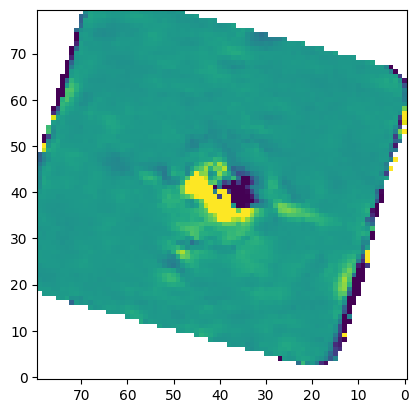

In [29]:
spline3d_suffix = "_SDI"
breadsPSF_basename_SDI = targetname+"_"+program+"_"+obsnum+"_"+grating+"_"+detector+spline3d_suffix+".fits"

wv_nodes_SDI_dict = {"G140H": {}, "G235H": {}, "G395H": {}}
wv_nodes_SDI_dict["G395H"]["nrs1"] = np.linspace(2.85, 4.119999999999999, 3, endpoint=True)
wv_nodes_SDI_dict["G395H"]["nrs2"] = np.linspace(4.07, 5.2999999999999945, 3, endpoint=True)

combdataobj = compute_3dsplines(cleaned_cal_files, utils_dir, simbad_name,combined_contnorm_spec_filename,
                                coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                                spline3d_suffix = spline3d_suffix,numthreads=numthreads,centroid_per_frame=True,
                                save_pickle=True, load_pickle=True,mask_charge_transfer_radius=None,
                                ra_dec_point_sources=ra_dec_point_sources,aper_rad=0.05,
                                wv_nodes=wv_nodes_SDI_dict[grating][detector])
# plot_3dspline_residuals(combdataobj,overwrite=False)

spline3d_filename_sdi = combdataobj.default_filenames["compute_starsubtraction_3dspline"]
breadspsf,breadspsf_err = create_BreadsPSF(spline3d_filename_sdi, x_vec, y_vec, wv_sampling,stis_spectrum=None,
                                           basename=breadsPSF_basename_SDI,numthreads=numthreads)

cube_mode = "ASDI"
suffix = "SDI"
splitbasename = os.path.basename(cleaned_cal_files[0]).split("_")
starsub_3dspline_SDI_filename = os.path.join(utils_dir,splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3]+"_starsub_combined_3Dspline"+"_SDI"+".fits")
contnorm_3dspline_SDI_filename = os.path.join(utils_dir,splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3]+"_starspec_contnorm_3Dspline"+"_SDI"+".fits")
#/stow/jruffio/data/JWST/nirspec/HIP_65426/obsnum05_8063/G395H_utils/jw08063005001_02101_nrs2
flux_cube4, fluxerr_cube4, x_grid, y_grid,wv_sampling = \
    cube_extraction(cleaned_cal_files, utils_dir, out_dir, combined_contnorm_spec_filename,
                    coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                    mode=cube_mode, suffix=suffix, contnorm_suffix=None,
                    ASDI_contnorm_3dspline_filename = contnorm_3dspline_SDI_filename, ASDI_starsub_3dspline_filename = starsub_3dspline_SDI_filename,
                x_vec=ra_vec, y_vec=dec_vec, wv_sampling=None,
                mask_charge_transfer_radius=None, ra_dec_point_sources=None,
                aper_radius=0.15,
                mppool=mypool,
                overwrite=False,
                targetname=simbad_name,
                use_stpsf=False,
                use_breadspsf=True,
                load_pickle=True,
                save_pickle=True,
                ifucoords=False)

cube_filename = os.path.join(out_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_" + grating + "_" + suffix + "_cube.fits")
out_filename = os.path.join(out_dir, f"{targetname}_{obsnum}_{detector}_{suffix}_1dspectrum.fits")
extract_spectrum(cube_filename,out_filename,xy_coords)


#############
# Plotting

plt.figure()
plt.imshow(np.nanmedian(flux_cube4[100:flux_cube4.shape[0]-100,:,:],axis=0),origin="lower")
plt.gca().invert_xaxis()
plt.clim([-5e-12,5e-12])

## Closing statements

In [ ]:
# close multiprocessing
mypool.close()
mypool.join()